## 1. Data Collection & Dataset Overview

In this study, we analyze how poverty levels and ethnic composition affect mortality rates across U.S. counties. The objective is to examine whether socioeconomic and demographic factors are associated with differences in health outcomes.

### Data Sources:

1. **U.S. Census Bureau (Poverty Data):** County-level poverty rates, representing the percentage of the population living below the poverty line.
2. **U.S. Census Bureau (Demographics Data):** County-level ethnic composition, including the population shares of Black, White, and Hispanic groups.
3. **Kaggle (Mortality Data):** County-level mortality rates (deaths per 100,000 individuals), compiled from publicly available health statistics.

### Dataset Characteristics:

The final dataset is constructed by merging three datasets using county-level identifiers. It contains the following key variables:

- **FIPS:** Unique county identifier used to merge datasets.
- **State & County:** Geographic identifiers for each observation.
- **poverty_rate:** Percentage of the population living below the poverty line (Census poverty dataset).
- **black, white, hispanic:** Share of each ethnic group in the county population (%) (Census demographics dataset).
- **mortality_rate:** Number of deaths per 100,000 individuals (Kaggle dataset).

The merged dataset includes approximately 3,000 U.S. counties and provides a comprehensive view of socioeconomic conditions, demographic composition, and mortality outcomes. This structure enables both exploratory analysis and statistical testing of the relationship between poverty, ethnicity, and mortality.

In [ ]:
import pandas as pd

pov = pd.read_csv("poverty2010.csv")
pov.columns = pov.columns.str.strip().str.lower()

pov = pov[[
    "state fips",
    "county fips",
    "postal",
    "name",
    "poverty percent all ages"
]].copy()

pov["state fips"] = pd.to_numeric(pov["state fips"], errors="coerce")
pov["county fips"] = pd.to_numeric(pov["county fips"], errors="coerce")
pov["poverty percent all ages"] = pd.to_numeric(pov["poverty percent all ages"], errors="coerce")

pov = pov.dropna(subset=["state fips", "county fips", "poverty percent all ages"])

pov = pov[pov["county fips"] != 0].copy()

pov["state fips"] = pov["state fips"].astype(int).astype(str).str.zfill(2)
pov["county fips"] = pov["county fips"].astype(int).astype(str).str.zfill(3)
pov["fips"] = pov["state fips"] + pov["county fips"]

pov = pov[["fips", "postal", "name", "poverty percent all ages"]].copy()
pov.columns = ["fips", "state", "county", "poverty_rate"]

pov = pov[pov["county"].str.lower().str.strip() != "united states"].copy()

pov["county"] = pov["county"].astype(str).str.strip()
pov["state"] = pov["state"].astype(str).str.strip().str.upper()


pov.head()

,fips,state,county,poverty_rate
2,01001,AL,Autauga County,11.9
3,01003,AL,Baldwin County,13.3
4,01005,AL,Barbour County,25.3
5,01007,AL,Bibb County,20.9
6,01009,AL,Blount County,16.5


In [ ]:
import pandas as pd
import re

demo = pd.read_csv("demographics.csv")
demo.columns = demo.columns.str.strip().str.lower()

demo = demo[[
    "county",
    "state",
    "ethnicities.black alone",
    "ethnicities.white alone",
    "ethnicities.hispanic or latino"
]].copy()

demo.columns = ["county", "state", "black", "white", "hispanic"]

demo["black"] = pd.to_numeric(demo["black"], errors="coerce")
demo["white"] = pd.to_numeric(demo["white"], errors="coerce")
demo["hispanic"] = pd.to_numeric(demo["hispanic"], errors="coerce")

demo["county"] = demo["county"].astype(str).str.strip()
demo["state"] = demo["state"].astype(str).str.strip().str.upper()

def normalize_county(x):
    x = str(x).lower().strip()
    x = re.sub(r' county$', '', x)
    x = re.sub(r' parish$', '', x)
    x = re.sub(r' borough$', '', x)
    x = re.sub(r' census area$', '', x)
    x = re.sub(r' municipality$', '', x)
    x = re.sub(r' city and borough$', '', x)
    x = re.sub(r'[^a-z ]', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x

demo["county_clean"] = demo["county"].apply(normalize_county)


demo.head()

,county,state,black,white,hispanic,county_clean
0,Abbeville County,SC,27.6,70.2,1.6,abbeville
1,Acadia Parish,LA,18.0,79.7,2.8,acadia
2,Accomack County,VA,28.8,67.8,9.1,accomack
3,Ada County,ID,1.4,91.9,8.5,ada
4,Adair County,IA,0.6,97.4,2.5,adair


In [ ]:
import pandas as pd


mort = pd.read_csv("mortality.csv")
mort.columns = mort.columns.str.strip().str.lower()

mort = mort[[
    "fips",
    "category",
    "mortality rate, 2010*"
]].copy()

mort.columns = ["fips", "category", "mortality_rate"]


mort["fips"] = pd.to_numeric(mort["fips"], errors="coerce")
mort["mortality_rate"] = pd.to_numeric(mort["mortality_rate"], errors="coerce")

mort = mort.dropna(subset=["fips", "mortality_rate"])

mort["fips"] = mort["fips"].astype(int).astype(str).str.zfill(5)

mort["category"] = mort["category"].astype(str).str.strip()


mort = mort[mort["category"] == "Cardiovascular diseases"].copy()


mort = mort.set_index("fips")


mort.head()

,category,mortality_rate
fips,,
00001,Cardiovascular diseases,310.55
01001,Cardiovascular diseases,316.82
01003,Cardiovascular diseases,279.98
01005,Cardiovascular diseases,264.63
01007,Cardiovascular diseases,374.27


In [66]:
import pandas as pd
import re

def normalize_county(x):
    x = str(x).lower().strip()
    x = re.sub(r' county$', '', x)
    x = re.sub(r' parish$', '', x)
    x = re.sub(r' borough$', '', x)
    x = re.sub(r' census area$', '', x)
    x = re.sub(r' municipality$', '', x)
    x = re.sub(r' city and borough$', '', x)
    x = re.sub(r'[^a-z ]', '', x)
    x = re.sub(r'\s+', ' ', x)
    return x

# clean county/state fields
pov["county"] = pov["county"].astype(str).str.strip()
pov["state"] = pov["state"].astype(str).str.strip().str.upper()
pov["county_clean"] = pov["county"].apply(normalize_county)

demo["county"] = demo["county"].astype(str).str.strip()
demo["state"] = demo["state"].astype(str).str.strip().str.upper()
demo["county_clean"] = demo["county"].apply(normalize_county)

# merge poverty + demographics
base = pd.merge(
    pov,
    demo,
    on=["state", "county_clean"],
    how="inner",
    suffixes=("_pov", "_demo")
)

base = base[[
    "fips",
    "state",
    "county_pov",
    "poverty_rate",
    "black",
    "white",
    "hispanic"
]].copy()

base.columns = [
    "fips",
    "state",
    "county",
    "poverty_rate",
    "black",
    "white",
    "hispanic"
]

# add mortality
data = pd.merge(
    base,
    mort,
    on="fips",
    how="inner"
)

# final column order
data = data[[
    "fips",
    "state",
    "county",
    "poverty_rate",
    "black",
    "white",
    "hispanic",
    "mortality_rate"
]].copy()

pd.set_option("display.max_rows", 10)
pd.set_option("display.min_rows", 5)
pd.set_option("display.max_columns", None)

data

,fips,state,county,poverty_rate,black,white,hispanic,mortality_rate
0,01001,AL,Autauga County,11.9,20.1,76.3,3.0,316.82
1,01003,AL,Baldwin County,13.3,8.8,87.4,4.7,279.98
...,...,...,...,...,...,...,...,...
3128,56043,WY,Washakie County,12.1,0.6,94.5,14.2,224.13
3129,56045,WY,Weston County,9.9,0.7,93.2,4.1,214.31


## 2. Exploratory Data Analysis (EDA)

In this section, we examine the relationships between poverty, ethnic composition, and mortality across U.S. counties. We first assess data quality, then explore overall patterns using summary statistics, and finally visualize how these variables are associated with each other.

### Step 1 — Checking Missing Values

Before starting the exploratory data analysis, I first checked whether the merged dataset contains any missing values. This step is important because missing observations can distort summary statistics, visualizations, and later regression results.

At this stage, the goal is to understand the general health of the dataset and see whether any variables require cleaning before analysis.

In [32]:
missing = data.isnull().sum().reset_index()
missing.columns = ["Variable", "Missing Count"]
print(missing)

         Variable  Missing Count
0            fips              0
1           state              0
2          county              0
3    poverty_rate              0
4           black              0
5           white              0
6        hispanic              0
7  mortality_rate              0


## Step 2 Summary Statistics and Extreme Values

The summary statistics indicate substantial variation across U.S. counties in both poverty and mortality rates. The average poverty rate is approximately 16.8%, while mortality rates average around 278 deaths per 100,000 individuals, suggesting notable disparities in socioeconomic and health outcomes.

The extreme values further highlight these differences. Ziebach County (SD) exhibits the highest poverty rate at 50.1%, whereas Falls Church city (VA) has the lowest at 3.1%. Similarly, Buffalo County (SD) records the highest mortality rate (539.93), while Pitkin County (CO) shows the lowest (79.29).

These findings suggest that certain counties experience significantly worse socioeconomic and health conditions, motivating further investigation into the relationship between poverty, demographic composition, and mortality.

In [ ]:


import pandas as pd

summary = data.describe().T[["mean", "std", "min", "max"]].round(2)

print("\n=== SUMMARY STATISTICS ===")
print(summary.to_string())


max_pov = data.loc[data["poverty_rate"].idxmax()]
min_pov = data.loc[data["poverty_rate"].idxmin()]
max_mort = data.loc[data["mortality_rate"].idxmax()]
min_mort = data.loc[data["mortality_rate"].idxmin()]

extremes = pd.DataFrame({
    "Metric": [
        "Highest Poverty",
        "Lowest Poverty",
        "Highest Mortality",
        "Lowest Mortality"
    ],
    "State": [
        max_pov["state"],
        min_pov["state"],
        max_mort["state"],
        min_mort["state"]
    ],
    "County": [
        max_pov["county"],
        min_pov["county"],
        max_mort["county"],
        min_mort["county"]
    ],
    "Value": [
        max_pov["poverty_rate"],
        min_pov["poverty_rate"],
        max_mort["mortality_rate"],
        min_mort["mortality_rate"]
    ]
})

print("\n=== EXTREME VALUES ===")
print(extremes.to_string(index=False))


=== SUMMARY STATISTICS ===
                  mean    std    min     max
poverty_rate     16.76   6.22   3.10   50.10
black             9.38  14.47  -1.00   86.60
white            84.43  16.24   8.00   99.00
hispanic          9.77  13.87   0.60   96.40
mortality_rate  278.51  56.23  79.29  539.93

=== EXTREME VALUES ===
           Metric State            County  Value
  Highest Poverty    SD    Ziebach County  50.10
   Lowest Poverty    VA Falls Church city   3.10
Highest Mortality    SD    Buffalo County 539.93
 Lowest Mortality    CO     Pitkin County  79.29


### Step 3 — Poverty vs Mortality

This scatter plot visualizes the relationship between poverty rate and mortality rate across counties. It helps assess whether higher poverty is associated with worse health outcomes.

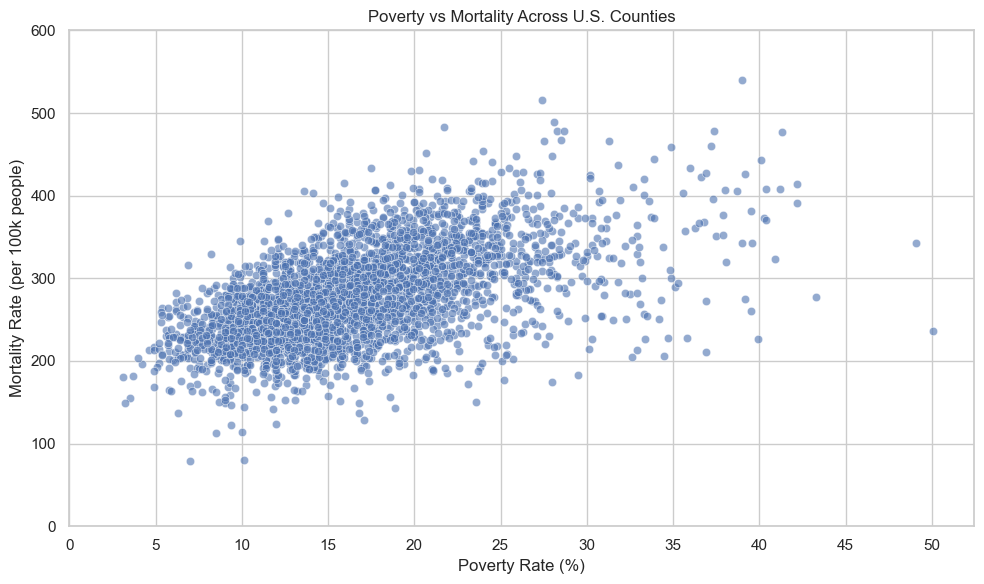

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="poverty_rate",
    y="mortality_rate",
    data=data,
    alpha=0.6
)

plt.title("Poverty vs Mortality Across U.S. Counties")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Mortality Rate (per 100k people)")

plt.yticks(np.arange(0, 601, 100))  # 0,100,200,...600

# istersen x-axis de sabitle
plt.xticks(np.arange(0, 51, 5))  # 0,5,10,...50

plt.tight_layout()
plt.show()


### Step 4 — Ethnic Composition and Mortality

This figure examines how the share of different ethnic groups (Black, White, and Hispanic) is associated with mortality rates across counties.

Each point represents a county, while the lines show the overall trend between the population share of each group and mortality.

The results suggest that:
- Counties with higher Black population shares tend to exhibit higher mortality rates (positive relationship).
- Counties with higher White and Hispanic population shares show a weaker or slightly negative relationship with mortality.

Overall, while poverty remains a key driver of mortality, the trends indicate that ethnic composition may also be associated with differences in health outcomes across regions.

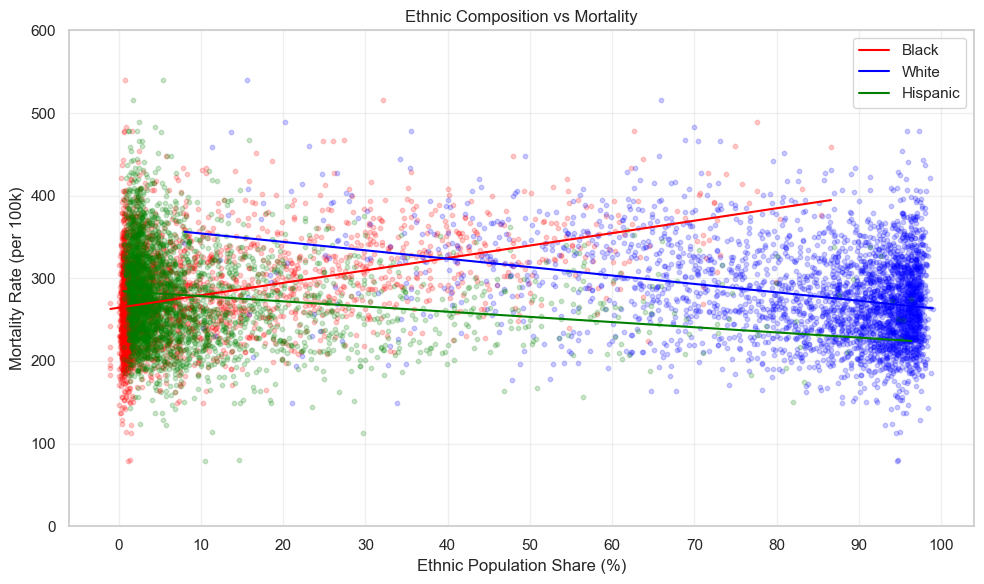

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

ethnicities = ["black", "white", "hispanic"]
colors = ["red", "blue", "green"]

for eth, color in zip(ethnicities, colors):
    x = data[eth]
    y = data["mortality_rate"]
    
    # scatter
    plt.scatter(x, y, alpha=0.2, s=10, color=color)
    
    # trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    
    plt.plot(x_line, y_line, color=color, label=eth.capitalize())

plt.xlabel("Ethnic Population Share (%)")
plt.ylabel("Mortality Rate (per 100k)")
plt.title("Ethnic Composition vs Mortality")


plt.yticks(np.arange(0, 601, 100))

plt.xticks(np.arange(0, 101, 10))

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3.HYPOTHESIS TESTING

To formally examine the relationship between poverty and mortality, we conduct a statistical hypothesis test using the Pearson correlation coefficient.

### Hypotheses

- **H₀ (Null Hypothesis):** There is no relationship between poverty rate and mortality rate.
- **H₁ (Alternative Hypothesis):** Higher poverty rates are associated with higher mortality rates.

### Method

We use the Pearson correlation coefficient to measure the strength and direction of the relationship, and evaluate statistical significance using the p-value.

### Significance Level

We use a significance level of **α = 0.05**.

In [57]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(data["poverty_rate"], data["mortality_rate"])

print("Correlation:", round(corr, 3))
print("P-value:", p_value)

Correlation: 0.553
P-value: 3.017876443218553e-250


## Results of Hypothesis Testing

The Pearson correlation coefficient is **0.553**, indicating a moderate positive relationship between poverty and mortality rates.

The p-value is below the significance level of 0.05, meaning the relationship is statistically significant.

### Conclusion

- **Result:** We reject the null hypothesis (H₀).
- **Interpretation:** There is strong statistical evidence that counties with higher poverty rates tend to have higher mortality rates.

This suggests that socioeconomic conditions play an important role in health outcomes.

In [58]:
if p_value < 0.05:
    print("Result: Reject H0 → Significant relationship")
else:
    print("Result: Fail to reject H0 → No significant relationship")

Result: Reject H0 → Significant relationship
